In [257]:
import numpy as np
from matplotlib import pyplot as plt
import matplotlib.ticker as ticker
from metpy.calc import moist_lapse
from metpy.units import units
import pandas as pd

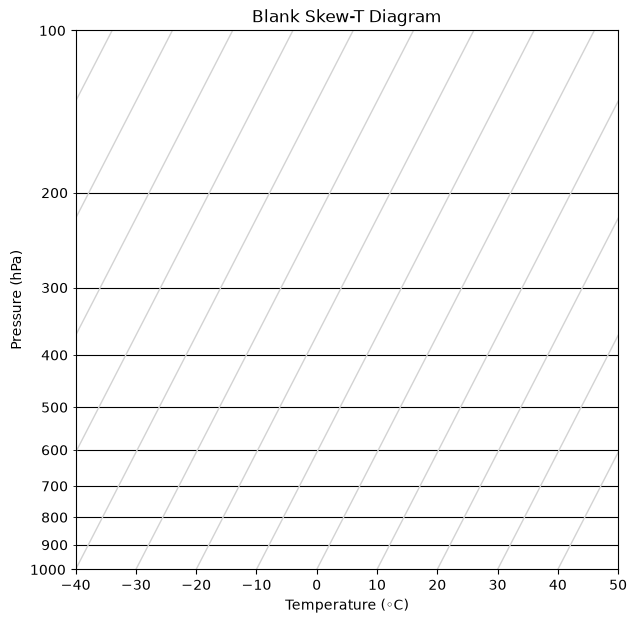

In [69]:
# blank SkewT with Isotherms
fig=plt.figure()
fig.set_size_inches(7,7)
ax=plt.axes()

ax.set_ylim(100,1000)
ax.set_yinverted(True)
ax.set_yscale('log')
ax.yaxis.set_major_formatter('{x:.0f}')
ax.yaxis.set_minor_formatter('{x:.0f}')
ax.grid(which='minor', axis='y', linestyle='-', color='k')

ax.set_title("Blank Skew-T Diagram")
ax.set_xlabel("Temperature (◦C)")
ax.set_ylabel("Pressure (hPa)")

ax.set_xlim(-40,50)

def skewT(temp, pres, skew=-20): #Skews the temperature axis for a SkewT plot.
    #temp: temperature values (deg C)
    #pres: pressure values (hPa)
    #skew: amount of skew (default of -20)
    return (temp) + skew * np.log(pres/1000.0)
#for t in 

temperature = np.arange(-80, 50, 10)
pressure = np.linspace(100, 1000, 100)
for t in temperature:
    skewed=skewT(t, pressure)
    ax.plot(skewed, pressure, color='lightgray', linestyle='-', linewidth=1)



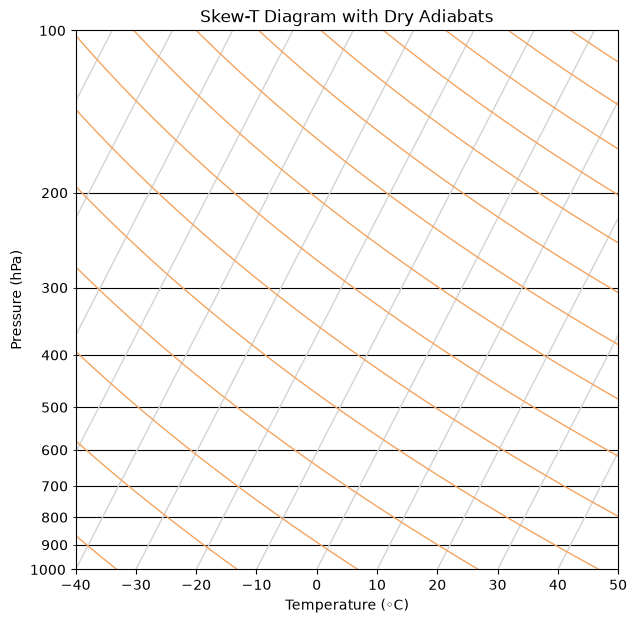

In [97]:
# SkewT with Isotherms and Dry Adiabats
fig=plt.figure()
fig.set_size_inches(7,7)
ax=plt.axes()

ax.set_ylim(100,1000)
ax.set_yinverted(True)
ax.set_yscale('log')
ax.yaxis.set_major_formatter('{x:.0f}')
ax.yaxis.set_minor_formatter('{x:.0f}')
ax.grid(which='minor', axis='y', linestyle='-', color='k')

ax.set_title("Skew-T Diagram with Dry Adiabats")
ax.set_xlabel("Temperature (◦C)")
ax.set_ylabel("Pressure (hPa)")

ax.set_xlim(-40,50)

def skewT(temp, pres, skew=-20): #Skews the temperature axis for a SkewT plot.
    #temp: temperature values (deg C)
    #pres: pressure values (hPa)
    #skew: amount of skew (default of -20)
    return (temp) + skew * np.log(pres/1000.0)
#for t in 

temperature = np.arange(-80, 50, 10)
pressure = np.linspace(100, 1000, 100)
for t in temperature:
    skewed=skewT(t, pressure)
    ax.plot(skewed, pressure, color='lightgray', linestyle='-', linewidth=1)

temperature2 = np.arange(-80, 50, 10)
rd= 287 #J kg−1 K−1,
cp= 1004 #J kg−1 K−1

finding_const_theta= 300 # K
d_theta= np.arange(200,600,20)

def dry_adiabat(theta, pres, init_pres=1000):
    return theta * ((pres/init_pres)**(rd/cp))

for theta in d_theta:
    adi_temp= dry_adiabat(theta, pressure)
    adi_temp_sk=skewT(adi_temp-273.15, pressure)
    ax.plot(adi_temp_sk, pressure, color='sandybrown', linestyle='-', linewidth=1)



In [221]:
def skewT(temp, pres, skew=-20): #Skews the temperature axis for a SkewT plot.
    #temp: temperature values (deg C)
    #pres: pressure values (hPa)
    #skew: amount of skew (default of -20)
    return (temp) + skew * np.log(pres/1000.0)
#for t in 

temperature = np.arange(-80, 50, 10)
pressure = np.linspace(100, 1000, 100)
for t in temperature:
    skewed=skewT(t, pressure)
    ax.plot(skewed, pressure, color='lightgray', linestyle='-', linewidth=1)


rd= 287 #J kg−1 K−1,
cp= 1004 #J kg−1 K−1
rv = 461 #J kg−1 K−1
lv = 2.5 * (10**6) #J kg−1. 
g= 9.81 #m s−2
eps= rd/rv

finding_const_theta= 300 # K
d_theta= np.arange(200,600,20)

def dry_adiabat(theta, pres, init_pres=1000):
    return theta * ((pres/init_pres)**(rd/cp))

#change moist adiabat eqn to pressure coordinates -> use HB and multiple by RdT/pg

def moist_adiabat(dry_adi_temp, pres):
    t_k=dry_adi_temp  #K
    es=6.112*(np.exp(17.67*(dry_adi_temp-273.15)/(dry_adi_temp-29.65))) #hPa
    rs=eps*(es/(pres-es)) #kg/kg
    theta_z_num=1+((lv*rs)/(rd*dry_adi_temp))
    theta_z_den=1+((rs*(lv**2))/(cp*rv*(dry_adi_temp**2)))
    theta_z=(g/cp)* (theta_z_num/theta_z_den)
    theta_p= theta_z*((rd*dry_adi_temp)/(pres*g))
    return theta_p

#print(moist_adiabat(temperature+273.15, 1000)*100)
#print (temperature)

#check
""
#print(moist_adiabat(0+273.15, pressure)*100)
#print (pressure)




''

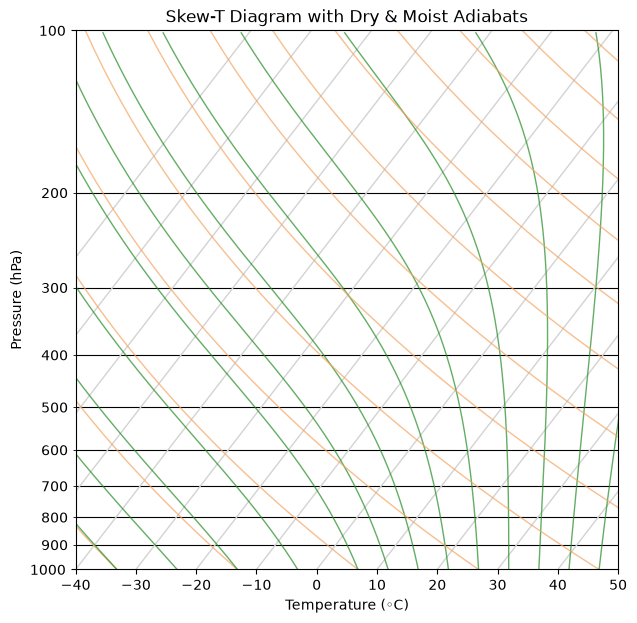

In [298]:
# SkewT with Isotherms and Moist Adiabats
fig=plt.figure()
fig.set_size_inches(7,7)
ax=plt.axes()

ax.set_ylim(100,1000)
ax.set_yinverted(True)
ax.set_yscale('log')
ax.yaxis.set_major_formatter('{x:.0f}')
ax.yaxis.set_minor_formatter('{x:.0f}')
ax.grid(which='minor', axis='y', linestyle='-', color='k')

ax.set_title("Skew-T Diagram with Dry & Moist Adiabats")
ax.set_xlabel("Temperature (◦C)")
ax.set_ylabel("Pressure (hPa)")

ax.set_xlim(-40,50)

def skewT(temp, pres, skew=-30): #Skews the temperature axis for a SkewT plot.
    #temp: temperature values (deg C)
    #pres: pressure values (hPa)
    #skew: amount of skew (default of -20)
    return (temp) + skew * np.log(pres/1000.0)
#for t in 

temperature = np.arange(-80, 50, 10)
pressure = np.linspace(100, 1000, 100)
for t in temperature:
    skewed=skewT(t, pressure)
    ax.plot(skewed, pressure, color='lightgray', linestyle='-', linewidth=1)


rd= 287 #J kg−1 K−1,
cp= 1004 #J kg−1 K−1
rv = 461 #J kg−1 K−1
lv = 2.5 * (10**6) #J kg−1. 
g= 9.81 #m s−2
eps= rd/rv

finding_const_theta= 300 # K
d_theta= np.arange(240,540,5)

def dry_adiabat(theta, pres, init_pres=1000):
    return theta * ((pres/init_pres)**(rd/cp))



#change moist adiabat eqn to pressure coordinates -> use HB and multiple by RdT/pg

def moist_adiabat(temp, pres):
    es=6.112*(np.exp(17.67*((temp-273.15)/(temp-29.65)))) #hPa
    rs=eps*(es/(pres-es)) #kg/kg
    theta_z_num=1+((lv*rs)/(rd*temp))
    theta_z_den=1+((rs*(lv**2))/(cp*rv*(temp**2)))
    theta_z=(-g/cp)* (theta_z_num/theta_z_den)
    theta_p= -theta_z*((rd*temp)/(pres*g))
    return theta_p

# give it a T inital and pressure inital 
# equal theta 0 values 
# how tou define the incriment 
#theta from dry adibat equation
#dt/dp
# 

#print(moist_adiabat(300))


hi_res_p=np.arange(100,1000,1)
hi_res_p2=np.arange(1000,100,-1)
#print(hi_res_p2)


for theta in d_theta:
    adi_temp= dry_adiabat(theta, pressure)
    adi_temp_sk=skewT(adi_temp-273.15, pressure)
    adi_moist=moist_adiabat(adi_temp[-1],1000)

    adi_moist_2=[]
    adi_moist_2.append(adi_temp[-1]-273.15)
    temp_interate=adi_temp[-1]-273.15
    for pres in list(range(len(hi_res_p2))):

        temp_interate = temp_interate-adi_moist
        adi_moist_2.append(temp_interate)
        adi_moist=moist_adiabat(temp_interate+273.15,hi_res_p2[pres])
    adi_moist_sk=skewT(adi_moist_2[:-1],hi_res_p2)
    if theta%4 ==0:
        ax.plot(adi_temp_sk, pressure, color='sandybrown', linestyle='-', linewidth=1,alpha=.7)
    if theta > 280:
        ax.plot(adi_moist_sk, hi_res_p2, color='forestgreen', linestyle='-', linewidth=1,alpha=.7)
    elif theta %2 ==0:
        ax.plot(adi_moist_sk, hi_res_p2, color='forestgreen', linestyle='-', linewidth=1,alpha=.7)


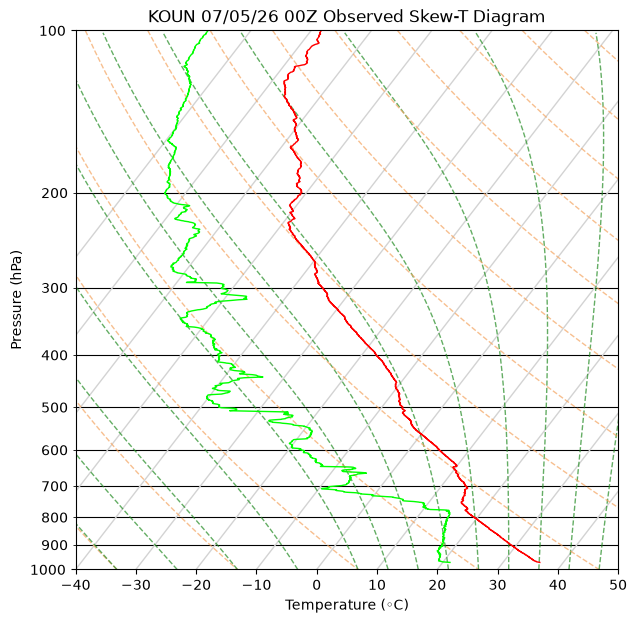

In [296]:
# SkewT with Isotherms, Dry Adiabats, Moist Adiabats, and a sounding T/Td data
fig=plt.figure()
fig.set_size_inches(7,7)
ax=plt.axes()

ax.set_ylim(100,1000)
ax.set_yinverted(True)
ax.set_yscale('log')
ax.yaxis.set_major_formatter('{x:.0f}')
ax.yaxis.set_minor_formatter('{x:.0f}')
ax.grid(which='minor', axis='y', linestyle='-', color='k')

ax.set_title("KOUN 07/05/26 00Z Observed Skew-T Diagram")
ax.set_xlabel("Temperature (◦C)")
ax.set_ylabel("Pressure (hPa)")

ax.set_xlim(-40,50)

def skewT(temp, pres, skew=-30): #Skews the temperature axis for a SkewT plot.
    #temp: temperature values (deg C)
    #pres: pressure values (hPa)
    #skew: amount of skew (default of -20)
    return (temp) + skew * np.log(pres/1000.0)
#for t in 

temperature = np.arange(-80, 50, 10)
pressure = np.linspace(100, 1000, 100)
for t in temperature:
    skewed=skewT(t, pressure)
    ax.plot(skewed, pressure, color='lightgray', linestyle='-', linewidth=1)

rd= 287 #J kg−1 K−1,
cp= 1004 #J kg−1 K−1

finding_const_theta= 300 # K
d_theta= np.arange(200,600,5)

def dry_adiabat(theta, pres, init_pres=1000):
    return theta * ((pres/init_pres)**(rd/cp))

#change moist adiabat eqn to pressure coordinates -> use HB and multiple by RdT/pg

def moist_adiabat(temp, pres):
    es=6.112*(np.exp(17.67*((temp-273.15)/(temp-29.65)))) #hPa
    rs=eps*(es/(pres-es)) #kg/kg
    theta_z_num=1+((lv*rs)/(rd*temp))
    theta_z_den=1+((rs*(lv**2))/(cp*rv*(temp**2)))
    theta_z=(-g/cp)* (theta_z_num/theta_z_den)
    theta_p= -theta_z*((rd*temp)/(pres*g))
    return theta_p

# give it a T inital and pressure inital 
# equal theta 0 values 
# how tou define the incriment 
#theta from dry adibat equation
#dt/dp
# 

#print(moist_adiabat(300))


hi_res_p=np.arange(100,1000,1)
hi_res_p2=np.arange(1000,100,-1)
#print(hi_res_p2)


for theta in d_theta:
    adi_temp= dry_adiabat(theta, pressure)
    adi_temp_sk=skewT(adi_temp-273.15, pressure)
    adi_moist=moist_adiabat(adi_temp[-1],1000)

    adi_moist_2=[]
    adi_moist_2.append(adi_temp[-1]-273.15)
    temp_interate=adi_temp[-1]-273.15
    for pres in list(range(len(hi_res_p2))):

        temp_interate = temp_interate-adi_moist
        adi_moist_2.append(temp_interate)
        adi_moist=moist_adiabat(temp_interate+273.15,hi_res_p2[pres])

    adi_moist_sk=skewT(adi_moist_2[:-1],hi_res_p2)
    if theta%4 ==0:
        ax.plot(adi_temp_sk, pressure, color='sandybrown', linestyle='--', linewidth=1,alpha=.7)
    if theta > 280:
        ax.plot(adi_moist_sk, hi_res_p2, color='forestgreen', linestyle='--', linewidth=1,alpha=.7)
    elif theta %2 ==0:
        ax.plot(adi_moist_sk, hi_res_p2, color='forestgreen', linestyle='--', linewidth=1,alpha=.7)


koun=pd.read_csv('2026070500-72357.csv')
#koun
obs_t=koun['temperature_C']
obs_td=koun['dew point temperature_C']
obs_p=koun['pressure_hPa']
skewed_obs=skewT(obs_t, obs_p)
skewed_obs_td=skewT(obs_td, obs_p)
ax.plot(skewed_obs, obs_p, color='red', linestyle='-', linewidth=1)
ax.plot(skewed_obs_td, obs_p, color='lime', linestyle='-', linewidth=1)



Interpretation prompts:
1. Why does the moist adiabatic lapse rate, Γm = −dT /dz, generally increase as a saturated parcel ascends and cools?

2. At a fixed pressure, how and why does Γm differ between warmer and colder moist adiabats?

3. “Break” your SkewT: test a wide range of skew values and describe what happens to the plot. What does this test teach you about the value of skewing? No need to show your tests; just describe your interpretations.


4. Describe two features of the sounding you chose to plot that you find particularly interesting or useful. Refer to specific pressure levels or layers and explain the physical significance of each feature.

5. What was the most challenging step for this lab? How did you navigate it, and what was the solution? If you leaned on GenAI tools, how did they contribute to your work and how did you check the information they provided?

I had trouble calculating lines of constant θ for my dry adibats. When I created my original function, it iterated over constant temperatures rather than constant θ. After attending office hours, I finally understood to switch the arguments and iterate over constant θ, to find the temperatures associated with this θ at each pressure level. 